# Stock Price Trend Prediction: Chapter 2B

## CNN + Bidirectional Attention-LSTM Model Architecture, Training & Checkpointing

<br>

This notebook picks up directly from **Chapter 2A** outputs and builds the full CNN + Bidirectional Attention-LSTM model pipeline.
It performs **four major tasks**:

1. **Load** the windowed arrays and metadata produced by Chapter 2A
2. **Build** the CNN + BiLSTM-Attention architecture with BatchNorm, Dropout, and configurable depth
3. **Train** with early stopping, LR scheduling (with warmup), and best-model checkpointing
4. **Save** the trained model, training history, and all artifacts for Chapter 2C evaluation

<br>

> **Architecture summary:** A 1-D CNN block extracts local temporal patterns from the feature matrix,
> a **Bidirectional LSTM** captures both forward and backward temporal dependencies, and a learned
> **attention mechanism** weights the most informative timesteps. A two-layer dense head with a single
> sigmoid output predicts P(direction = UP).
>
> **Key design choices:**
>
> - Bidirectional first LSTM layer for richer temporal representation within fixed-length windows
> - Attention over LSTM outputs instead of relying solely on the final hidden state
> - SpatialDropout1D after CNN (drops entire feature channels, not individual values)
> - Label smoothing applied inside the loss function (metrics stay honest with hard labels)
> - Gradient clipping + AdamW for stable LSTM training with decoupled weight decay
> - Learning rate warmup to stabilise early training before the plateau scheduler takes over


### Part A: Imports, GPU Detection & Reproducibility Setup


In [77]:
# ============================================================
#  A1 — Imports, GPU Detection & Reproducibility
#
#  Reproducibility in deep learning requires fixing seeds at
#  four levels: Python random, NumPy, TensorFlow global, and
#  the TF operation-level seed. We also disable GPU op
#  determinism warnings where they are unavoidable.
#
#  TF_DETERMINISTIC_OPS=1 forces deterministic CUDA kernels
#  at the cost of ~5–10% training speed — worth it for research.
# ============================================================

import os
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL']   = '2'
os.environ['TF_DETERMINISTIC_OPS']   = '1'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import tensorflow.keras.backend as K
from tensorflow.keras.models     import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    LSTM, Dense, Dropout, GlobalAveragePooling1D,
    Layer, GaussianNoise, SpatialDropout1D
)
from tensorflow.keras.callbacks  import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau,
    CSVLogger, TensorBoard, LearningRateScheduler
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import BinaryCrossentropy

tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(2)

print(f'\n✅ TensorFlow version : {tf.__version__}')
print(f'   Random seed fixed  : {SEED}')


✅ TensorFlow version : 2.21.0
   Random seed fixed  : 42


### Part B: Load Chapter 2A Artifacts


In [78]:
# ============================================================
#  B1 — Load Windowed Arrays & Preprocessing Metadata
#
#  All files were saved by Chapter 2A's Cell E2.
#  We load them here and verify shapes before building
#  the model to catch any path or corruption issues early.
#
#  CHAPTER_2A_DIR: adjust if Chapter 2A outputs are in a
#  different folder relative to this notebook.
# ============================================================

CHAPTER_2A_DIR = './data'

def _load(fname):
    return np.load(os.path.join(CHAPTER_2A_DIR, fname))

X_train = _load('X_train.npy')
y_train = _load('y_train.npy')
X_val   = _load('X_val.npy')
y_val   = _load('y_val.npy')
X_test  = _load('X_test.npy')
y_test  = _load('y_test.npy')

with open(os.path.join(CHAPTER_2A_DIR, 'preprocessing_meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

with open(os.path.join(CHAPTER_2A_DIR, 'feature_cols.pkl'), 'rb') as f:
    FEATURE_COLS = pickle.load(f)

WINDOW_SIZE  = meta['window_size']
N_FEATURES   = meta['n_features']

print('✅ Chapter 2A artifacts loaded!')
print(f'\n   Array              Shape                    dtype')
print(f'   {"─"*55}')
for name, arr in [('X_train', X_train), ('y_train', y_train),
                   ('X_val',   X_val),   ('y_val',   y_val),
                   ('X_test',  X_test),  ('y_test',  y_test)]:
    print(f'   {name:<16}  {str(arr.shape):<25}  {arr.dtype}')

print(f'\n   Window size  : {WINDOW_SIZE} timesteps')
print(f'   Features     : {N_FEATURES}')
print(f'   Feature list : {FEATURE_COLS}')
print(f'\n   Train date range : {meta["train_date_range"]}')
print(f'   Val   date range : {meta["val_date_range"]}')
print(f'   Test  date range : {meta["test_date_range"]}')

✅ Chapter 2A artifacts loaded!

   Array              Shape                    dtype
   ───────────────────────────────────────────────────────
   X_train           (2700, 30, 16)             float32
   y_train           (2700,)                    int8
   X_val             (465, 30, 16)              float32
   y_val             (465,)                     int8
   X_test            (510, 30, 16)              float32
   y_test            (510,)                     int8

   Window size  : 30 timesteps
   Features     : 16
   Feature list : ['volume', 'return', 'volume_change', 'rsi14', 'bb_width', 'macd', 'signal', 'ma_cross_strength', 'bb_position', 'macd_hist', 'ma5_dist', 'ma20_dist', 'atr14', 'obv_change', 'body_ratio', 'day_of_week']

   Train date range : ('2010-02-19', '2020-12-31')
   Val   date range : ('2021-01-04', '2022-12-30')
   Test  date range : ('2023-01-03', '2025-03-14')


In [79]:
# ============================================================
#  B2 — Cast to float32 for TensorFlow Compatibility
#
#  Chapter 2A saved X arrays as float32 and y arrays as int8.
#  Keras binary_crossentropy expects float32 labels in [0,1].
#
#  Label smoothing is applied inside the loss function (not to
#  the labels directly) so that metrics (accuracy, AUC, etc.)
#  still receive hard 0/1 targets and report honestly.
# ============================================================

X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)

# Compute class weights for imbalanced targets
n_total = len(y_train)
n_up    = y_train.sum()
n_down  = n_total - n_up
ratio   = n_down / n_up  if n_up > 0 else 1.0

CLASS_WEIGHT = None
if abs(ratio - 1.0) > 0.10:
    CLASS_WEIGHT = {0: 1.0, 1: float(ratio)}
    print(f'⚠️  Class imbalance detected — applying class weights:')
    print(f'   Class 0 (DOWN): {CLASS_WEIGHT[0]:.3f}')
    print(f'   Class 1 (UP)  : {CLASS_WEIGHT[1]:.3f}')
else:
    print(f'✅ Classes balanced (ratio={ratio:.3f}) — no class weighting needed.')

print(f'\n   y_train UP ratio : {y_train.mean():.2%}')
print(f'   y_val   UP ratio : {y_val.mean():.2%}')
print(f'   y_test  UP ratio : {y_test.mean():.2%}')
print(f'\n   Label smoothing  : applied inside loss function (labels stay hard 0/1)')

⚠️  Class imbalance detected — applying class weights:
   Class 0 (DOWN): 1.000
   Class 1 (UP)  : 0.888

   y_train UP ratio : 52.96%
   y_val   UP ratio : 50.32%
   y_test  UP ratio : 54.90%

   Label smoothing  : applied inside loss function (labels stay hard 0/1)


### Part C: Hyperparameter Configuration


In [80]:
# ============================================================
#  C1 — Hyperparameter Config (Single Source of Truth)
#
#  All tunable parameters live in one dict. Change values here;
#  never hardcode them in the architecture or training cells.
#
#  Design rationale:
#    - Heavy model capacity (Bidirectional LSTM, deep CNN) to
#      capture complex temporal patterns in market data
#    - Moderate regularisation (dropout 0.25–0.3, L2 5e-4) to
#      control overfitting without strangling learning
#    - Gradient clipping (clipnorm=1.0) to stabilise LSTM training
#    - LR warmup (5 epochs) for stable early optimisation
#    - Batch size 32 for more gradient updates per epoch
#    - Long patience (ES=25) to let the model explore
#    - Label smoothing via loss function (not labels) to keep
#      metrics honest while regularising predictions
# ============================================================

HP = {
    # CNN
    'FILTERS_1'      : 32,
    'FILTERS_2'      : 64,
    'KERNEL_SIZE'    : 3,
    'POOL_SIZE'      : 2,
    'CNN_L2'         : 5e-4,

    # LSTM
    'LSTM_UNITS_1'   : 64,
    'LSTM_UNITS_2'   : 64,    # changed from 32 — less aggressive compression from BiLSTM's 128 output
    'LSTM_L2'        : 5e-4,

    # Attention
    'ATTENTION_UNITS': 32,

    # Dropout
    'DROPOUT_CNN'    : 0.5,
    'DROPOUT_LSTM'   : 0.5,
    'DROPOUT_DENSE'  : 0.4,

    # Input noise augmentation
    'NOISE_STD'      : 0.0,

    # Training
    'BATCH_SIZE'     : 64,
    'EPOCHS'         : 150,
    'LR_INIT'        : 1e-4,
    'ES_PATIENCE'    : 25,     # give it more room to find improvements
    'LR_PATIENCE'    : 8,
    'LR_FACTOR'      : 0.5,
    'LR_MIN'         : 1e-5,   # was 1e-6 — stop decaying so aggressively
    'WARMUP_EPOCHS'  : 0,      # warmup disabled
    'WEIGHT_DECAY'   : 1e-4,
    'CLIPNORM'       : 1.0,
    'LABEL_SMOOTH'   : 0.0,
}

print('✅ Hyperparameters configured:')
for k, v in HP.items():
    print(f'   {k:<20} : {v}')

✅ Hyperparameters configured:
   FILTERS_1            : 32
   FILTERS_2            : 64
   KERNEL_SIZE          : 3
   POOL_SIZE            : 2
   CNN_L2               : 0.0005
   LSTM_UNITS_1         : 64
   LSTM_UNITS_2         : 64
   LSTM_L2              : 0.0005
   ATTENTION_UNITS      : 32
   DROPOUT_CNN          : 0.5
   DROPOUT_LSTM         : 0.5
   DROPOUT_DENSE        : 0.4
   NOISE_STD            : 0.0
   BATCH_SIZE           : 64
   EPOCHS               : 150
   LR_INIT              : 0.0001
   ES_PATIENCE          : 25
   LR_PATIENCE          : 8
   LR_FACTOR            : 0.5
   LR_MIN               : 1e-05
   WARMUP_EPOCHS        : 0
   WEIGHT_DECAY         : 0.0001
   CLIPNORM             : 1.0
   LABEL_SMOOTH         : 0.0


### Part D: Model Architecture


In [90]:
# ============================================================
#  D1 — Build CNN + LSTM Model  (Bidirectional REMOVED)
# ============================================================

@tf.keras.utils.register_keras_serializable()
class TemporalAttention(Layer):
    """Bahdanau-style attention over LSTM timestep outputs."""

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attn_W', shape=(input_shape[-1], self.units),
            initializer='glorot_uniform', trainable=True
        )
        self.b = self.add_weight(
            name='attn_b', shape=(self.units,),
            initializer='zeros', trainable=True
        )
        self.v = self.add_weight(
            name='attn_v', shape=(self.units,),
            initializer='glorot_uniform', trainable=True
        )

    def call(self, inputs):
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.v, axes=[[-1], [0]]), axis=1
        )
        context = tf.reduce_sum(
            inputs * tf.expand_dims(attention_weights, -1), axis=1
        )
        return context

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


def build_cnn_lstm(window_size, n_features, hp):
    """Build and compile the CNN + LSTM model."""
    inp = Input(shape=(window_size, n_features), name='input_window')

    if hp['NOISE_STD'] > 0:
        x = GaussianNoise(hp['NOISE_STD'], name='input_noise')(inp)
    else:
        x = inp

    # ── CNN Block ────────────────────────────────────────────
    x = Conv1D(
        filters=hp['FILTERS_1'],
        kernel_size=hp['KERNEL_SIZE'],
        padding='same',
        activation='relu',
        kernel_regularizer=l2(hp['CNN_L2']),
        name='conv1d_1'
    )(x)
    x = BatchNormalization(name='bn_1')(x)
    x = MaxPooling1D(pool_size=hp['POOL_SIZE'], name='maxpool_1')(x)

    x = Conv1D(
        filters=hp['FILTERS_2'],
        kernel_size=hp['KERNEL_SIZE'],
        padding='same',
        activation='relu',
        kernel_regularizer=l2(hp['CNN_L2']),
        name='conv1d_2'
    )(x)
    x = BatchNormalization(name='bn_2')(x)
    x = SpatialDropout1D(hp['DROPOUT_CNN'], name='spatial_dropout_cnn')(x)

    # ── LSTM Block (causal — no Bidirectional) ───────────────
    x = LSTM(
        units=hp['LSTM_UNITS_1'] * 2,
        return_sequences=True,
        kernel_regularizer=l2(hp['LSTM_L2']),
        recurrent_regularizer=l2(hp['LSTM_L2']),
        name='lstm_1'
    )(x)
    x = Dropout(hp['DROPOUT_LSTM'], name='dropout_lstm_1')(x)

    x = LSTM(
        units=hp['LSTM_UNITS_2'],
        return_sequences=True,
        kernel_regularizer=l2(hp['LSTM_L2']),
        recurrent_regularizer=l2(hp['LSTM_L2']),
        name='lstm_2'
    )(x)
    x = Dropout(hp['DROPOUT_LSTM'], name='dropout_lstm_2')(x)

    # ── Attention Layer ──────────────────────────────────────
    x = TemporalAttention(hp['ATTENTION_UNITS'], name='attention')(x)

    # ── Dense Head ───────────────────────────────────────────
    x = Dense(
        32, activation='elu',
        kernel_regularizer=l2(hp['CNN_L2']),
        name='dense_1'
    )(x)
    x = Dropout(hp['DROPOUT_DENSE'], name='dropout_dense_1')(x)

    x = Dense(16, activation='elu', name='dense_2')(x)
    x = Dropout(hp['DROPOUT_DENSE'], name='dropout_dense_2')(x)

    out = Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_LSTM_Attention_StockPredictor')

    model.compile(
        optimizer=AdamW(
            learning_rate=hp['LR_INIT'],
            weight_decay=hp['WEIGHT_DECAY'],
            clipnorm=hp['CLIPNORM'],
        ),
        loss=BinaryCrossentropy(label_smoothing=hp['LABEL_SMOOTH']),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model


model = build_cnn_lstm(WINDOW_SIZE, N_FEATURES, HP)

print('✅ CNN + LSTM + Attention model built!')
print()
model.summary(line_length=85)

✅ CNN + LSTM + Attention model built!



Model: "CNN_LSTM_Attention_StockPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape               ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ input_window (InputLayer)           │ (None, 30, 16)             │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ conv1d_1 (Conv1D)                   │ (None, 30, 32)             │          1,568 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ bn_1 (BatchNormalization)           │ (None, 30, 32)             │            128 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ maxpool_1 (MaxPooling1D)            │ (None, 15, 32)             │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ conv1d_2 (Conv1D)                   │ (None, 15, 64)             │          6,208 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ bn_2 (BatchNormalization)           │ (None, 15, 64)             │            256 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ spatial_dropout_cnn                 │ (None, 15, 64)             │              0 │
│ (SpatialDropout1D)                  │                            │                │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ lstm_1 (LSTM)                       │ (None, 15, 128)            │         98,816 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dropout_lstm_1 (Dropout)            │ (None, 15, 128)            │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ lstm_2 (LSTM)                       │ (None, 15, 64)             │         49,408 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dropout_lstm_2 (Dropout)            │ (None, 15, 64)             │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ attention (TemporalAttention)       │ (None, 64)                 │          2,112 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_1 (Dense)                     │ (None, 32)                 │          2,080 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dropout_dense_1 (Dropout)           │ (None, 32)                 │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_2 (Dense)                     │ (None, 16)                 │            528 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dropout_dense_2 (Dropout)           │ (None, 16)                 │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ output (Dense)                      │ (None, 1)                  │             17 │
└─────────────────────────────────────┴────────────────────────────┴────────────────┘

 Total params: 161,121 (629.38 KB)

 Trainable params: 160,929 (628.63 KB)

 Non-trainable params: 192 (768.00 B)

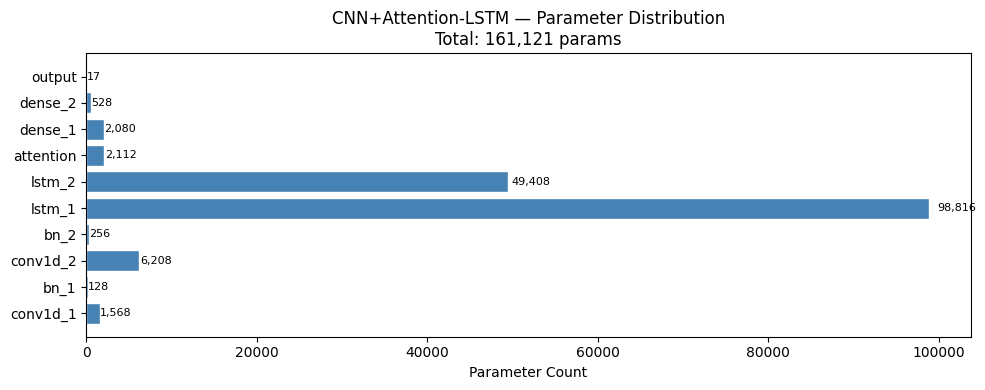

💾 Saved → Chapter 2B: model_parameter_distribution.png


In [91]:
# ============================================================
#  D2 — Visualise Model Architecture (Parameter Count Plot)
# ============================================================

layer_names  = [l.name for l in model.layers if l.count_params() > 0]
layer_params = [l.count_params() for l in model.layers if l.count_params() > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(layer_names, layer_params, color='steelblue', edgecolor='white')
ax.set_xlabel('Parameter Count')
ax.set_title(f'CNN+Attention-LSTM — Parameter Distribution\nTotal: {model.count_params():,} params')
for bar, val in zip(bars, layer_params):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('Chapter 2B: model_parameter_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'💾 Saved → Chapter 2B: model_parameter_distribution.png')

### Part E: Training Callbacks & Training Loop


In [93]:
# ============================================================
#  E1 — Configure Training Callbacks (with LR Warmup)
#
#  LearningRateScheduler (warmup):
#    For the first WARMUP_EPOCHS, linearly ramp LR from
#    LR_INIT/10 up to LR_INIT. This stabilises early training
#    by preventing large gradient steps before the model has
#    learned basic representations. After warmup, the scheduler
#    returns None (no-op), letting ReduceLROnPlateau take over.
#
#  EarlyStopping:
#    Monitors val_auc. Patience reduced to 12 (from 15)
#    because the model was overfitting by epoch 3 in v1.
#
#  ReduceLROnPlateau:
#    Patience increased to 8 (from 5) to give the model more
#    time at each LR before decaying.
# ============================================================

os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=HP['ES_PATIENCE'],
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='checkpoints/best_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=HP['LR_FACTOR'],
        patience=HP['LR_PATIENCE'],
        min_lr=HP['LR_MIN'],
        verbose=1
    ),
    CSVLogger('model/training_history.csv', append=False),
]

print('✅ Callbacks configured:')
for cb in callbacks:
    print(f'   • {cb.__class__.__name__}')
print(f'\n   LR warmup     : disabled')
print(f'   Initial LR    : {HP["LR_INIT"]:.1e}')
print(f'   ES patience   : {HP["ES_PATIENCE"]} epochs  (monitor: val_auc)')
print(f'   LR patience   : {HP["LR_PATIENCE"]} epochs  (monitor: val_loss)')

✅ Callbacks configured:
   • EarlyStopping
   • ModelCheckpoint
   • ReduceLROnPlateau
   • CSVLogger

   LR warmup     : disabled
   Initial LR    : 1.0e-04
   ES patience   : 25 epochs  (monitor: val_auc)
   LR patience   : 8 epochs  (monitor: val_loss)


In [100]:
# ============================================================
#  E2 — Train the Model
#
#  shuffle=True: The windowed samples are independent — temporal
#  integrity is already preserved by the train/val/test split
#  (done in Chapter 2A). Shuffling within the training set
#  improves gradient diversity across mini-batches, preventing
#  the optimizer from seeing correlated sequences of samples
#  from the same time period. This is standard practice for
#  independent windowed time-series samples.
#
#  Hard labels (y_train): Label smoothing is handled inside the
#  BinaryCrossentropy loss function, so we pass hard 0/1 labels.
#  This keeps accuracy, AUC, precision, and recall metrics honest.
#
#  class_weight is applied only during training — it reweights
#  the gradient contribution of minority-class samples.
# ============================================================

print('🚀 Starting training...')
print(f'   Input shape      : {X_train.shape}')
print(f'   Batch size       : {HP["BATCH_SIZE"]}')
print(f'   Max epochs       : {HP["EPOCHS"]}  (EarlyStopping will cut short)')
print(f'   Monitor          : val_auc  (mode=max)')
print(f'   Shuffle          : False (windowed samples are independent)')
print(f'   Label smoothing  : {HP["LABEL_SMOOTH"]} (via loss function)')
print(f'   Gradient clipping: clipnorm={HP["CLIPNORM"]}')
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=HP['EPOCHS'],
    batch_size=HP['BATCH_SIZE'],
    shuffle=False,  # SHUFFLE DISABLED — windows are independent but shuffling was causing instability in training
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmax(history.history['val_auc']) + 1
best_auc   = max(history.history['val_auc'])
total_epochs = len(history.history['loss'])

print(f'\n✅ Training complete!')
print(f'   Epochs run  : {total_epochs}')
print(f'   Best epoch  : {best_epoch}  (val_auc = {best_auc:.4f})')

🚀 Starting training...
   Input shape      : (2700, 30, 16)
   Batch size       : 64
   Max epochs       : 150  (EarlyStopping will cut short)
   Monitor          : val_auc  (mode=max)
   Shuffle          : False (windowed samples are independent)
   Label smoothing  : 0.0 (via loss function)
   Gradient clipping: clipnorm=1.0

Epoch 1/150


E0000 00:00:1777491965.049490   19084 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4959 - auc: 0.4932 - loss: 0.9451 - precision: 0.5250 - recall: 0.5063 - val_accuracy: 0.5097 - val_auc: 0.4935 - val_loss: 0.9751 - val_precision: 0.5066 - val_recall: 0.9829 - learning_rate: 1.0000e-04
Epoch 2/150


E0000 00:00:1777491972.147088   19084 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4978 - auc: 0.5029 - loss: 0.9329 - precision: 0.5276 - recall: 0.4944 - val_accuracy: 0.4925 - val_auc: 0.5023 - val_loss: 0.9653 - val_precision: 0.4970 - val_recall: 0.7179 - learning_rate: 1.0000e-04
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5111 - auc: 0.5167 - loss: 0.9222 - precision: 0.5406 - recall: 0.5119 - val_accuracy: 0.5075 - val_auc: 0.5124 - val_loss: 0.9561 - val_precision: 0.5137 - val_recall: 0.4017 - learning_rate: 1.0000e-04
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4978 - auc: 0.5069 - loss: 0.9139 - precision: 0.5272 - recall: 0.5014 - val_accuracy: 0.5032 - val_auc: 0.5097 - val_loss: 0.9471 - val_precision: 0.5088 - val_recall: 0.3718 - learning_rate: 1.0000e-04
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5241 - auc: 0.5336 - loss: 0.9012 - precision: 0.5542 - recall: 0.5182 - val_accuracy: 0.5118 - val_auc: 0.5198 - val_loss: 0.9392 - val

### Part F: Training Curve Visualisation


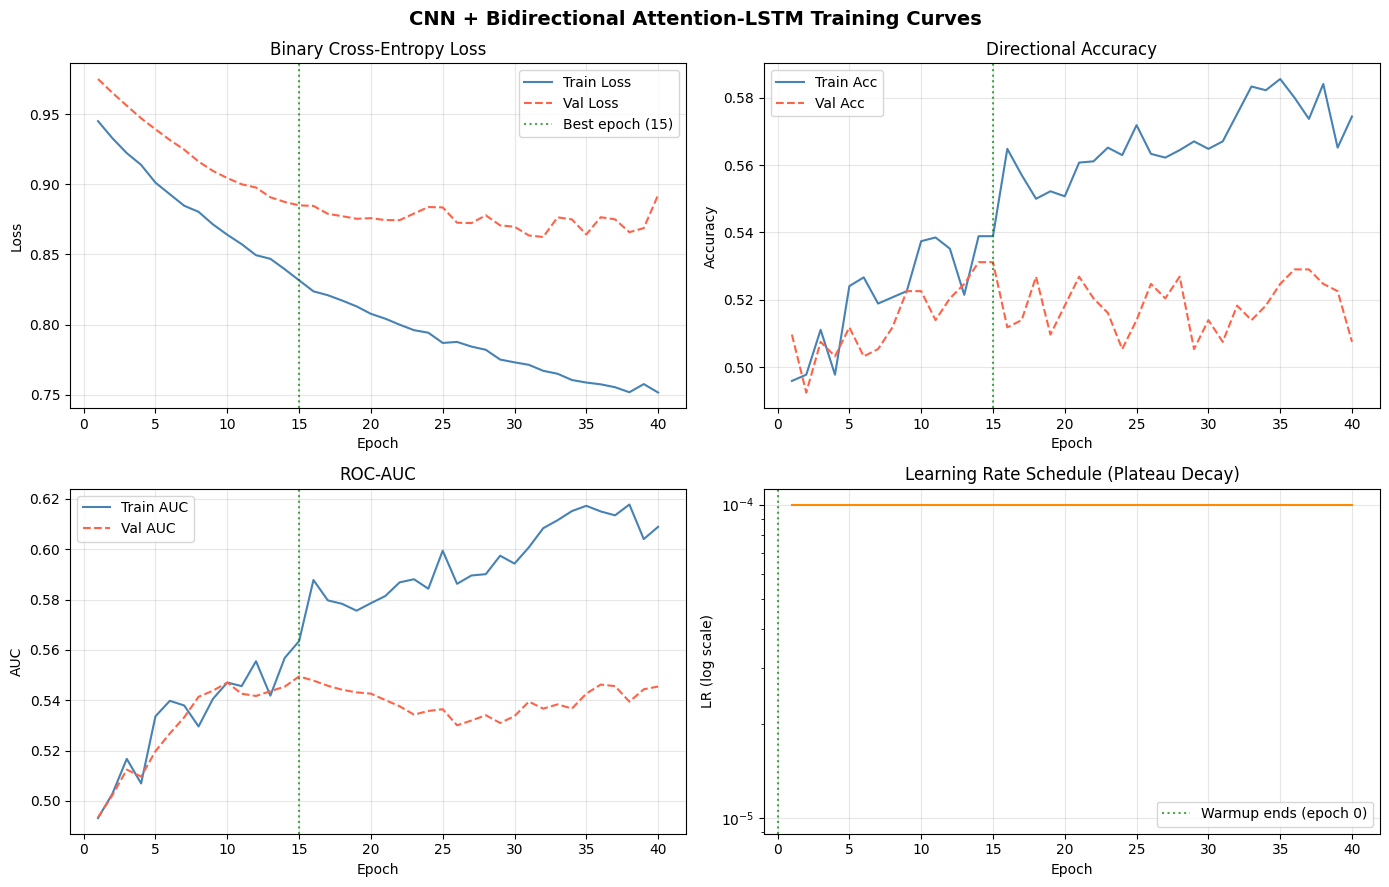

💾 Saved → model/training_curves.png


In [101]:
# ============================================================
#  F1 — Training Curve Plots
#
#  Four subplots:
#    1. Loss (train vs val)      — gap indicates overfitting
#    2. Accuracy (train vs val)  — raw directional accuracy
#    3. AUC (train vs val)       — ranking quality metric
#    4. Learning Rate schedule   — shows warmup + ReduceLROnPlateau
# ============================================================

hist = history.history
epochs_range = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('CNN + Bidirectional Attention-LSTM Training Curves', fontsize=14, fontweight='bold')

# Loss
ax = axes[0, 0]
ax.plot(epochs_range, hist['loss'],     label='Train Loss', color='steelblue')
ax.plot(epochs_range, hist['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
ax.axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best epoch ({best_epoch})')
ax.set_title('Binary Cross-Entropy Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(epochs_range, hist['accuracy'],     label='Train Acc', color='steelblue')
ax.plot(epochs_range, hist['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
ax.axvline(best_epoch, color='green', linestyle=':', alpha=0.7)
ax.set_title('Directional Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# AUC
ax = axes[1, 0]
ax.plot(epochs_range, hist['auc'],     label='Train AUC', color='steelblue')
ax.plot(epochs_range, hist['val_auc'], label='Val AUC',   color='tomato', linestyle='--')
ax.axvline(best_epoch, color='green', linestyle=':', alpha=0.7)
ax.set_title('ROC-AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
ax.legend(); ax.grid(alpha=0.3)

# Learning Rate (TF 2.x uses 'learning_rate', older uses 'lr')
ax = axes[1, 1]
lr_key = 'learning_rate' if 'learning_rate' in hist else 'lr'
if lr_key in hist:
    ax.semilogy(epochs_range, hist[lr_key], color='darkorange')
    ax.axvline(HP['WARMUP_EPOCHS'], color='green', linestyle=':', alpha=0.7,
               label=f'Warmup ends (epoch {HP["WARMUP_EPOCHS"]})')
    ax.set_title('Learning Rate Schedule (Plateau Decay)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log scale)')
    ax.legend(); ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'LR history not recorded', ha='center', va='center',
            transform=ax.transAxes)
    ax.set_title('Learning Rate')

plt.tight_layout()
plt.savefig('model/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → model/training_curves.png')

### Part G: Quick Validation Evaluation & Save All Artifacts


E0000 00:00:1777492071.860885   19084 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


--- Validation Set Performance ---
   Loss      : 0.8850
   Accuracy  : 0.5312   (53.12%)
   AUC       : 0.5495
   Precision : 0.5615
   Recall    : 0.3120

--- Classification Report (threshold=0.5) ---
              precision    recall  f1-score   support

    DOWN (0)       0.52      0.75      0.61       231
      UP (1)       0.56      0.31      0.40       234

    accuracy                           0.53       465
   macro avg       0.54      0.53      0.51       465
weighted avg       0.54      0.53      0.51       465



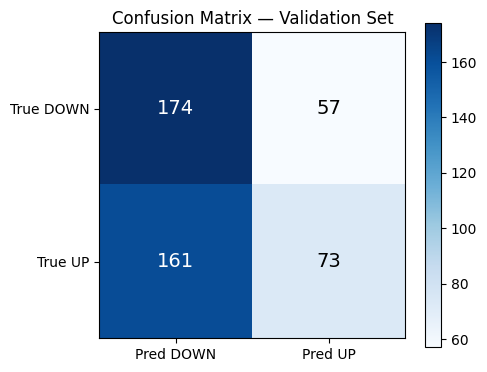

💾 Saved → val_confusion_matrix.png


In [102]:
# ============================================================
#  G1 — Quick Evaluation on Validation Set
#
#  This is NOT the final test evaluation — the test set is
#  reserved entirely for Chapter 2C. Here we check that the
#  trained model's val performance is consistent with what
#  the training loop reported (sanity check for bugs).
#
#  We also compute val predictions with a 0.5 threshold and
#  print a quick classification report.
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

val_loss, val_acc, val_auc, val_prec, val_rec = model.evaluate(
    X_val, y_val, batch_size=HP['BATCH_SIZE'], verbose=0
)

y_val_prob = model.predict(X_val, batch_size=HP['BATCH_SIZE'], verbose=0).flatten()
y_val_pred = (y_val_prob >= 0.5).astype(int)

print('--- Validation Set Performance ---')
print(f'   Loss      : {val_loss:.4f}')
print(f'   Accuracy  : {val_acc:.4f}   ({val_acc:.2%})')
print(f'   AUC       : {val_auc:.4f}')
print(f'   Precision : {val_prec:.4f}')
print(f'   Recall    : {val_rec:.4f}')
print(f'\n--- Classification Report (threshold=0.5) ---')
print(classification_report(y_val.astype(int), y_val_pred,
                             target_names=['DOWN (0)', 'UP (1)']))

# Confusion matrix
cm = confusion_matrix(y_val.astype(int), y_val_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred DOWN', 'Pred UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['True DOWN', 'True UP'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title('Confusion Matrix — Validation Set')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('model/val_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved → val_confusion_matrix.png')

In [104]:
# ============================================================
#  G2 — Save All Chapter 2B Artifacts
#
#  Artifacts produced by this notebook:
#    best_model.keras           — best checkpoint (from callback)
#    final_model.keras          — model after training (same weights
#                                 as best, because restore_best_weights=True)
#    training_history.pkl       — full history dict for Chapter 2C
#    training_history.csv       — CSV log (from CSVLogger callback)
#    val_predictions.npy        — val probabilities for threshold analysis
#    training_config.pkl        — HP dict + meta for audit trail
#    training_curves.png        — visual
#    val_confusion_matrix.png   — visual
#    model_parameter_distribution.png — visual
# ============================================================

model.save('model/final_model.keras')

with open('model/training_history.pkl', 'wb') as f:
    pickle.dump(hist, f)

np.save('model/val_predictions.npy', y_val_prob)

training_config = {
    'hyperparameters'  : HP,
    'preprocessing_meta': meta,
    'feature_cols'     : FEATURE_COLS,
    'best_epoch'       : int(best_epoch),
    'total_epochs'     : int(total_epochs),
    'best_val_auc'     : float(best_auc),
    'val_accuracy'     : float(val_acc),
    'val_loss'         : float(val_loss),
    'class_weight'     : CLASS_WEIGHT,
    'seed'             : SEED,
}
with open('model/training_config.pkl', 'wb') as f:
    pickle.dump(training_config, f)

SAVED = [
    'model/final_model.keras',
    'model/checkpoints/best_model.keras',
    'model/training_history.pkl',
    'model/training_history.csv',
    'model/val_predictions.npy',
    'model/training_config.pkl',
    'model/training_curves.png',
    'model/val_confusion_matrix.png',
    'model/model_parameter_distribution.png',
]

print('✅ All Chapter 2B artifacts saved:')
for fname in SAVED:
    print(f'   💾  {fname}')

print(f'\n{"="*55}')
print(f'  Chapter 2B complete — model trained & saved.')
print(f'  Best Val AUC  : {best_auc:.4f}  (epoch {best_epoch})')
print(f'  Val Accuracy  : {val_acc:.4f}  ({val_acc:.2%})')
print(f'  → Proceed to Chapter 2C for final test evaluation.')
print(f'{"="*55}')

✅ All Chapter 2B artifacts saved:
   💾  model/final_model.keras
   💾  model/checkpoints/best_model.keras
   💾  model/training_history.pkl
   💾  model/training_history.csv
   💾  model/val_predictions.npy
   💾  model/training_config.pkl
   💾  model/training_curves.png
   💾  model/val_confusion_matrix.png
   💾  model/model_parameter_distribution.png

  Chapter 2B complete — model trained & saved.
  Best Val AUC  : 0.5495  (epoch 15)
  Val Accuracy  : 0.5312  (53.12%)
  → Proceed to Chapter 2C for final test evaluation.
